In [ ]:
# -----------------------------------------------------------------------------
# Curl (Rotation) of a 3D vector field f = (fx, fy, fz)
# -----------------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Domain & sampling (vectorized grid)
# -----------------------------
vmin, vmax = -1.0, 1.0
ds = 0.25                                # grid step
n_points = int((vmax - vmin) / ds) + 1   # include endpoint

x = np.linspace(vmin, vmax, n_points)
y = np.linspace(vmin, vmax, n_points)
z = np.linspace(vmin, vmax, n_points)

dx = x[1] - x[0]
dy = y[1] - y[0]
dz = z[1] - z[0]

# Meshgrid with (y, x, z) array order matching 'indexing="xy"'
X, Y, Z = np.meshgrid(x, y, z, indexing="xy")

# -----------------------------
# Define vector field f = (fx, fy, fz)
# Choose ONE example (uncomment to switch)
# -----------------------------

# Example 1 (default): 0.5*(y*z^2, -x*z^2, 0)
fx = 0.5 * Y * (Z**2)
fy = -0.5 * X * (Z**2)
fz = 0.0 * Z
title_str = r"vec f = 0.5(yz^2-xz^2,0)"

# Example 2:
# fx = Y * (Z**2);  fy = -X * (Z**2);  fz = 0.0 * Z
# title_str = r"vec f = (yz^2-xz^2.0)"

# Example 3:
# fx = X*Y;  fy = Y*Z;  fz = Z*X
# title_str = r"vec f = (x y,\; y z,\; z x)"

# Example 4:
# fx = -Y;  fy = X;  fz = 0.0 * Z
# title_str = r"vec f = (-y,\; x,\; 0)"

# -----------------------------
# Curl (Rotation): ∇×f
# np.gradient on array [y, x, z] returns (∂/∂y, ∂/∂x, ∂/∂z)
# -----------------------------
dfx_dy, dfx_dx, dfx_dz = np.gradient(fx, dy, dx, dz)
dfy_dy, dfy_dx, dfy_dz = np.gradient(fy, dy, dx, dz)
dfz_dy, dfz_dx, dfz_dz = np.gradient(fz, dy, dx, dz)

curl_x = dfz_dy - dfy_dz
curl_y = dfx_dz - dfz_dx
curl_z = dfy_dx - dfx_dy

# 2D vorticity (circulation) on a z-slice equals curl_z slice
m = n_points // 2 + 0
m = min(m, n_points - 1)
z_m = z[m]

Xs, Ys = X[:, :, m], Y[:, :, m]
fx2, fy2 = fx[:, :, m], fy[:, :, m]
omega_z = curl_z[:, :, m]


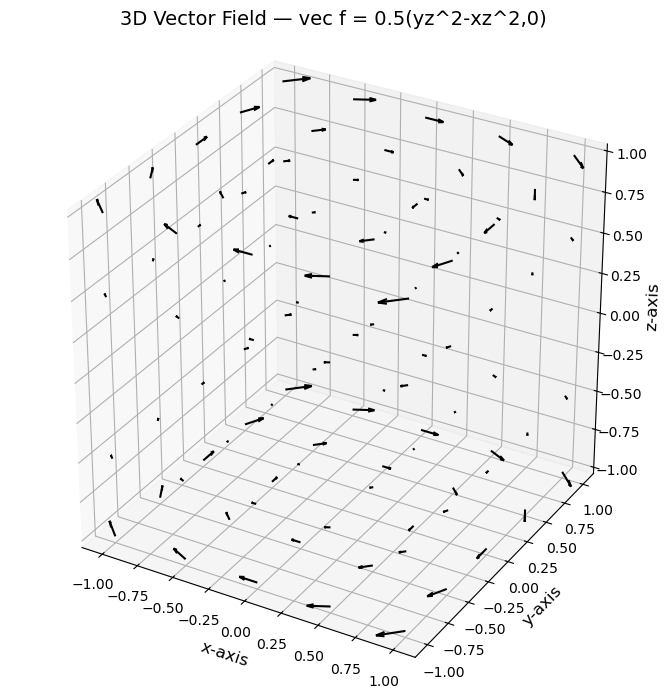

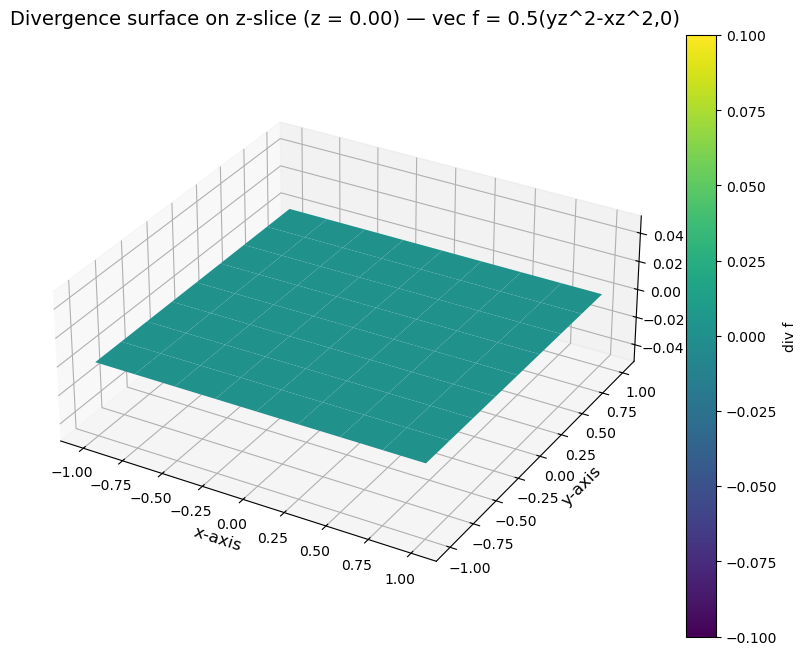

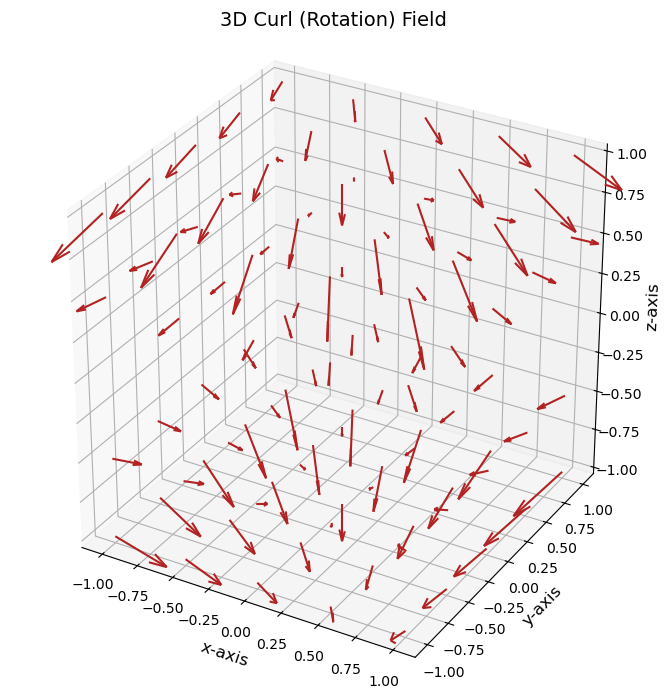

In [8]:

# -----------------------------
# 3D quiver: vector field
# -----------------------------
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

step = 2  # downsample for visual clarity
ax.quiver(
    X[::step, ::step, ::step],
    Y[::step, ::step, ::step],
    Z[::step, ::step, ::step],
    fx[::step, ::step, ::step],
    fy[::step, ::step, ::step],
    fz[::step, ::step, ::step],
    colors='black',
    length=0.25, normalize=False
)

ax.set_xlabel('x-axis', fontsize=12)
ax.set_ylabel('y-axis', fontsize=12)
ax.set_zlabel('z-axis', fontsize=12)
ax.set_title(f'3D Vector Field — {title_str}', fontsize=14)
ax.set_box_aspect((1, 1, 1))
plt.tight_layout()
plt.show()

# -----------------------------
# Curl (Rotation) on a fixed z-slice: surface + colorbar
# -----------------------------
Xs, Ys = X[:, :, m], Y[:, :, m]


fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    Xs, Ys, omega_z,
    cmap='viridis', linewidth=0, antialiased=True, shade=True
)
fig.colorbar(surf, label='div f', shrink=0.9)

ax.set_xlabel('x-axis', fontsize=12)
ax.set_ylabel('y-axis', fontsize=12)
ax.set_zlabel('div f', fontsize=12)
ax.set_title(f'Divergence surface on z-slice (z = {z_m:.2f}) — {title_str}', fontsize=14)

# Proportional appearance (x:y:z box ratio); z can be adjusted as needed
ax.set_box_aspect((1, 1, 0.4))

plt.tight_layout()
plt.show()

# -----------------------------
# 3D quiver: curl (rotation) field
# -----------------------------
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

ax.quiver(
    X[::step, ::step, ::step],
    Y[::step, ::step, ::step],
    Z[::step, ::step, ::step],
    curl_x[::step, ::step, ::step],
    curl_y[::step, ::step, ::step],
    curl_z[::step, ::step, ::step],
    length=0.25, normalize=False, color="firebrick"
)

ax.set_xlabel('x-axis', fontsize=12)
ax.set_ylabel('y-axis', fontsize=12)
ax.set_zlabel('z-axis', fontsize=12)
ax.set_title('3D Curl (Rotation) Field', fontsize=14)
ax.set_box_aspect((1, 1, 1))
plt.tight_layout()
plt.show()
